---

# 🚀 현대의 MLOps
## 클라우드 네이티브 환경에서의 머신러닝 시스템

---

## 🌟 클라우드 네이티브 환경이란?

현대의 MLOps는 클라우드 네이티브 환경에서 여러 대의 서버를 유기적으로 활용해 움직입니다.
전통적인 온프레미스(On-premise) 환경과 달리, 언제든지 자원을 늘리고 줄일 수 있는 유연성이 특징입니다.

**핵심 기술 요소:**
- 🐳 **컨테이너 가상화 (Docker)**
- ☸️ **오케스트레이션 (Kubernetes)**
- 📬 **메시지 큐 (Message Queue)**
- 🔄 **CI/CD 파이프라인**

---
## 🐳 1. 컨테이너 가상화 (Docker)

> *"제 컴퓨터(환경)에서는 잘 되는데 서버에서는 안 돌아가요"*

- **고질적인 문제 해결**: 개발 환경과 운영 환경의 불일치를 컨테이너 이미징을 통해 완벽하게 해소합니다.
- **컨테이너 격리 기술**:
  - **cgroups (Control Groups)**: 각 컨테이너가 사용할 수 있는 시스템 리소스(CPU, 메모리 등)의 한도를 설정하여 특정 앱의 자원 독점을 방지합니다.
  - **namespace**: 프로세스, 네트워크, 파일 시스템 등을 완전히 격리하여 독립된 공간을 제공합니다.
- **장점**: 무거운 OS 전체를 가상화하는 일반 VM에 비해 훨씬 가볍고 빠르게 동작합니다.

### 🔹 아키텍처 비교도 (VM vs Docker)
```mermaid
graph TD
    subgraph VM [Virtual Machine]
        V_OS1[Guest OS] --> V_App1[App A]
        V_OS2[Guest OS] --> V_App2[App B]
        Hypervisor --> V_OS1
        Hypervisor --> V_OS2
        Host_OS1[Host OS] --> Hypervisor
    end
    subgraph Docker [Container]
        D_Engine[Docker Engine] --> D_App1[App A]
        D_Engine[Docker Engine] --> D_App2[App B]
        Host_OS2[Host OS] --> D_Engine
    end
```

### 👨‍💻 [연습 시뮬레이션] 컨테이너 리소스 격리 시각화 (Matplotlib)
만약 하나의 서버에 여러 앱을 올렸을 때, Docker의 `cgroups`가 없다면 특정 모델 서빙 앱이 자원을 100% 독점하여 다른 앱들을 다운시킬 수 있습니다. 이를 시각적으로 비교해봅시다.

In [1]:
import importlib.util
import subprocess
import sys

packages = ("numpy", "matplotlib")
missing = [package for package in packages if importlib.util.find_spec(package) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

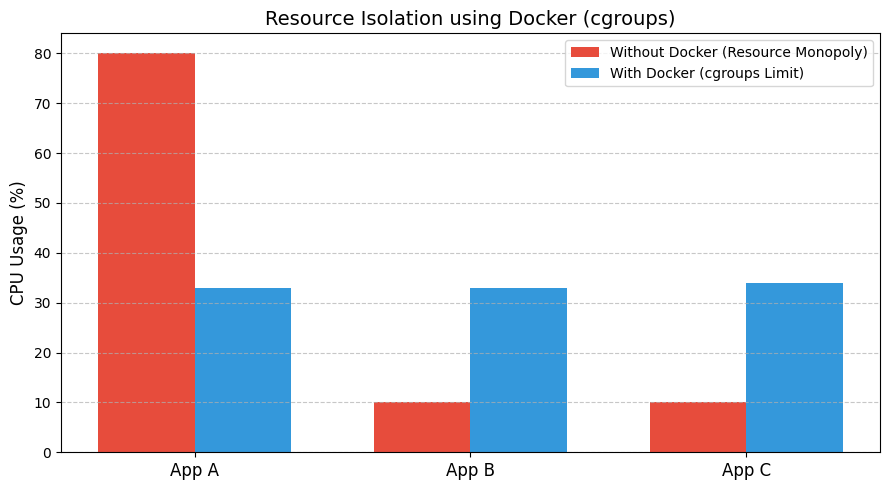

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 컨테이너 환경 vs 비컨테이너 환경의 리소스 할당 시뮬레이션
labels = ['App A', 'App B', 'App C']
no_container = [80, 10, 10]  # App A가 자원을 독점하는 상황
with_container = [33, 33, 34] # cgroups를 통해 자원을 균등하게 제한한 상황

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, no_container, width, label='Without Docker (Resource Monopoly)', color='#e74c3c')
rects2 = ax.bar(x + width/2, with_container, width, label='With Docker (cgroups Limit)', color='#3498db')

ax.set_ylabel('CPU Usage (%)', fontsize=12)
ax.set_title('Resource Isolation using Docker (cgroups)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## ☸️ 2. 오케스트레이션 (Kubernetes)

**분산 환경의 기초: 수십, 수백 개의 컨테이너를 사람이 직접 모니터링하고 관리할 수 있을까요?**

- **자동 확장 (HPA: Horizontal Pod Autoscaler)**: 사용자의 트래픽 증감에 맞춰 모델 서빙 컨테이너의 갯수를 스스로 판단하여 늘리거나 줄입니다.
- **무중단 배포 (Rolling Update)**: 서비스 중단 현상 없이, 과거 버전의 컨테이너를 새로운 버전으로 점진적으로 교체합니다.
- **자가 치유 (Self-healing)**: 뻗어버린 서버 컨테이너를 감지하고 즉시 새로운 컨테이너로 재시작합니다.

### 🔹 쿠버네티스 HPA(Auto-scaling) 흐름도
```mermaid
sequenceDiagram
    participant User as 사용자 트래픽
    participant Ingress as API Gateway
    participant HPA as K8s HPA 컨트롤러
    participant Pods as 모델 서빙 Pods
    
    User->>Ingress: 초당 1,000건의 추론 트래픽 인입
    Ingress->>Pods: 요청 전달
    Pods-->>HPA: CPU / Memory 사용량 80% 돌파 보고
    HPA->>Pods: 부하 분산을 위해 Pod 복제본 동적 증가 (Scale-Out)
```

### 👨‍💻 [연습 시뮬레이션] 트래픽 변화에 따른 파드 자동 확장 시각화
하루 24시간 동안 트래픽이 몰리는 피크 시간대에 쿠버네티스가 어떻게 동적으로 파드(Pod)를 늘려 대응하는지 보여줍니다.

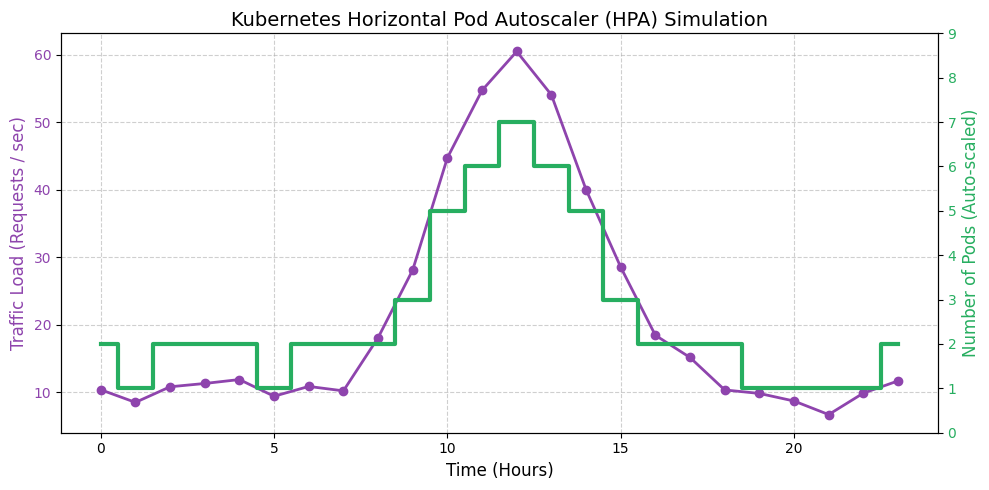

In [3]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(0, 24)
# 점심 시간(12시) 부근에 트래픽이 집중되는 패턴
traffic = 10 + 50 * np.exp(-((time - 12) / 3)**2) + np.random.normal(0, 2, 24)
traffic = np.maximum(traffic, 0) # 트래픽이 0 이하로 떨어지지 않도록 보정
pods = np.ceil(traffic / 10)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#8e44ad'
ax1.set_xlabel('Time (Hours)', fontsize=12)
ax1.set_ylabel('Traffic Load (Requests / sec)', color=color1, fontsize=12)
ax1.plot(time, traffic, color=color1, marker='o', linewidth=2, label='Traffic Load')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color2 = '#27ae60'
ax2.set_ylabel('Number of Pods (Auto-scaled)', color=color2, fontsize=12)
ax2.step(time, pods, color=color2, where='mid', label='Running Pods', linewidth=3)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, max(pods) + 2)

plt.title('Kubernetes Horizontal Pod Autoscaler (HPA) Simulation', fontsize=14)
fig.tight_layout()
plt.show()

---
## 📬 3. 메시지 큐 (Message Queue)

**이벤트 드리븐(Event-Driven) 환경에서 병목을 방지하는 완충 지대**

- **주요 솔루션**: Kafka, RabbitMQ
- **발행-구독 (Pub/Sub) 모델**:
  - **Publisher**: 데이터를 만들어내는 주체 (예: 실시간 사용자 클릭 로그)
  - **Subscriber**: 큐에 쌓인 데이터를 가져가 비동기로 처리하는 주체 (예: 실시간 추천 모델 서빙 로직)
- 모델 추론 속도보다 데이터 유입 속도가 더 빠를 때, 데이터 유실 없이 큐에 잠시 담아두어 시스템 부하를 방지합니다.

### 🔹 Pub/Sub 메시지 큐 아키텍처
```mermaid
graph LR
    P1[클릭 로그 (Producer)] -->|Publish| MQ[(Kafka / RabbitMQ)]
    P2[결제 내역 (Producer)] -->|Publish| MQ
    MQ -->|Subscribe (Pull)| S1[실시간 상품 추천 모델]
    MQ -->|Subscribe (Pull)| S2[이상 거래 탐지 모델]
```

### 👨‍💻 [연습 시뮬레이션] 스파이크 트래픽 발생 시 MQ의 버퍼링 효과 시각화
초당 처리할 수 있는 추론량은 한정되어 있는데, 순간적인 트래픽이 몰릴 때 메시지 큐가 어떻게 충격을 흡수하는지 확인합니다.

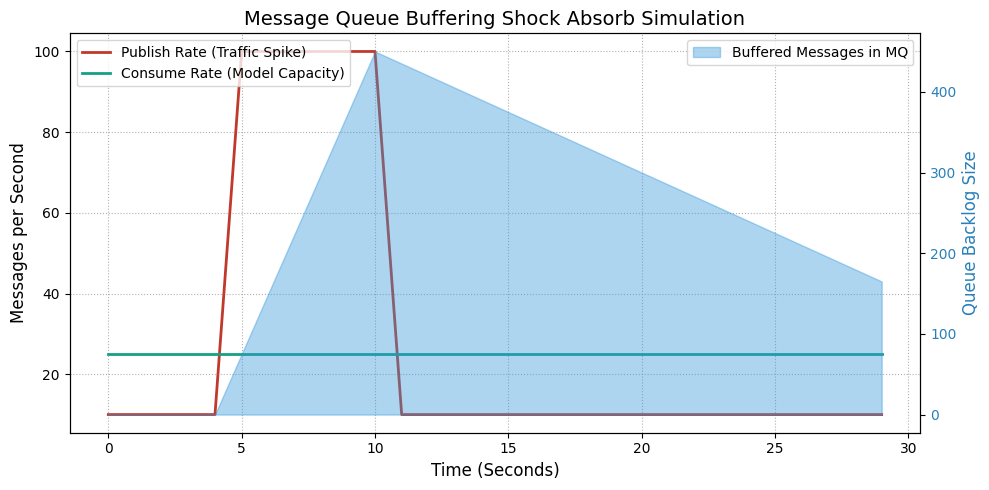

In [4]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(0, 30)
# 5~10초 구간에 엄청난 트래픽 스파이크 발생
publish_rate = np.where((time >= 5) & (time <= 10), 100, 10)  
consume_rate = np.full(30, 25) # 컨슈머(모델)는 초당 25개씩 꾸준히 처리

queue_backlog = np.zeros(30)
for i in range(1, 30):
    # 이전 큐 잔량 + 새로 들어온 량 - 처리한 량
    queue_backlog[i] = max(0, queue_backlog[i-1] + publish_rate[i] - consume_rate[i])

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Time (Seconds)', fontsize=12)
ax1.set_ylabel('Messages per Second', fontsize=12)
ax1.plot(time, publish_rate, label='Publish Rate (Traffic Spike)', color='#c0392b', linestyle='-', linewidth=2)
ax1.plot(time, consume_rate, label='Consume Rate (Model Capacity)', color='#16a085', linewidth=2)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':')

ax2 = ax1.twinx()
ax2.set_ylabel('Queue Backlog Size', color='#2980b9', fontsize=12)
ax2.fill_between(time, queue_backlog, color='#3498db', alpha=0.4, label='Buffered Messages in MQ')
ax2.tick_params(axis='y', labelcolor='#2980b9')
ax2.legend(loc='upper right')

plt.title('Message Queue Buffering Shock Absorb Simulation', fontsize=14)
fig.tight_layout()
plt.show()

---
## 🔄 4. CI/CD 파이프라인

**사람의 개입을 최소화하여 인적 오류를 방지하고 배포 신뢰성을 확보**

- **CI (Continuous Integration)**: 데이터 사이언티스트가 코드를 수정하거나 모델을 업데이트했을 때, 이를 자동으로 단위 테스트하고 도커 이미지로 빌드합니다.
- **CD (Continuous Deployment)**: CI를 통과한 새로운 버전을 Staging 또는 Production 쿠버네티스 클러스터에 무중단으로 릴리스합니다.
- MLOps에서는 여기에 **CT (Continuous Training)** 파이프라인까지 결합하여 데이터 드리프트 감지 시 재학습까지 자동화합니다.

### 🔹 머신러닝 파이프라인 자동화 흐름
```mermaid
graph LR
    Commit[Code Push] --> CI[CI: Lint & Test]
    CI --> Build[Docker Build]
    Build --> Registry[(Image Registry)]
    Registry --> CD[CD: K8s Deploy]
    CD --> Prod[Production 서빙]
```

### 👨‍💻 [연습 시뮬레이션] CI/CD 파이프라인 소요 시간 간트 차트 (Gantt Chart)
코드 푸시부터 운영 서버에 배포되기까지 각 자동화 단계별로 걸리는 시간을 직관적으로 살펴봅니다.

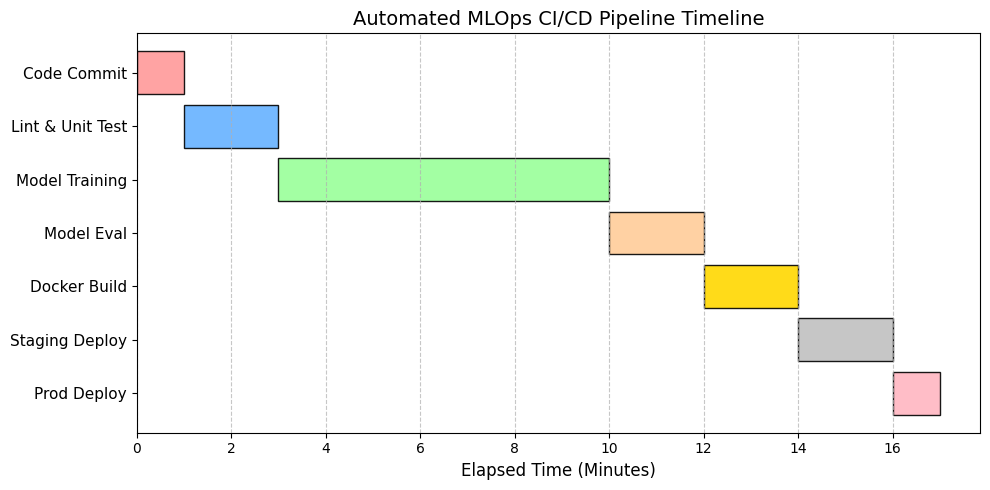

In [5]:
import matplotlib.pyplot as plt
import numpy as np

tasks = ['Code Commit', 'Lint & Unit Test', 'Model Training', 'Model Eval', 'Docker Build', 'Staging Deploy', 'Prod Deploy']
start_times = [0, 1, 3, 10, 12, 14, 16]
durations = [1, 2, 7, 2, 2, 2, 1]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(tasks))

# 파스텔톤 컬러셋
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#C0C0C0', '#FFB6C1']

ax.barh(y_pos, durations, left=start_times, align='center', color=colors, edgecolor='black', alpha=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks, fontsize=11)
ax.invert_yaxis()  # 진행 순서가 위에서 아래로 가도록 뒤집기
ax.set_xlabel('Elapsed Time (Minutes)', fontsize=12)
ax.set_title('Automated MLOps CI/CD Pipeline Timeline', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 🎯 요약 및 마무리

성공적인 MLOps는 단순히 성능 좋은 모델을 만드는 것을 넘어, **인프라와 시스템을 얼마나 유기적으로 묶어 자동화**하느냐에 달려있습니다.

1. 🐳 **Docker**: 파편화 없는 안정적이고 일관된 모델 실행 환경 보장
2. ☸️ **Kubernetes**: 트래픽 증감에도 끄떡없는 자동 확장 서빙 클러스터 구축
3. 📬 **Message Queue**: 병목현상을 예방하는 실시간 비동기 데이터 파이프라인
4. 🔄 **CI/CD/CT**: 배포 시간을 획기적으로 단축시키는 신뢰성 높은 자동화

<br>
